In [1]:
import h5py
import anndata as ad
import pandas as pd
import numpy as np
import scipy.sparse as sp
import scanpy as sc
import harmonypy as hm

In [2]:
adata = sc.read_h5ad("/Users/likai/Downloads/BICAN_MiniAtlas_HQcell_BGC_STR_MSN.h5ad")

=== Region counts ===
region
Pu      78265
CaB     75731
CaH     71095
NAC     55542
GP      28544
CaT     13514
STH         7
MGM1        5
Name: count, dtype: int64

=== CaB_Pu_NAC_STXBP6_GNAS: mean expression ===
          STXBP6      GNAS
region                    
NAC     0.521515  0.261658
Pu      1.685134  0.069137
CaB     2.808137  0.049663

=== CaB_Pu_NAC_STXBP6_GNAS: z-scored expression ===
          STXBP6      GNAS
region                    
NAC    -1.005868  1.150707
Pu      0.011841 -0.492257
CaB     0.994027 -0.658450

=== CaB_Pu_NAC_STXBP6_GNAS: percent expressing cells ===
           STXBP6       GNAS
region                      
NAC     20.184725  18.992834
Pu      54.528844   5.526097
CaB     69.975307   4.203034


/var/folders/_r/b3mmx0vn61xg9lj08b924y_h0000gn/T/ipykernel_41676/2020733302.py:235: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


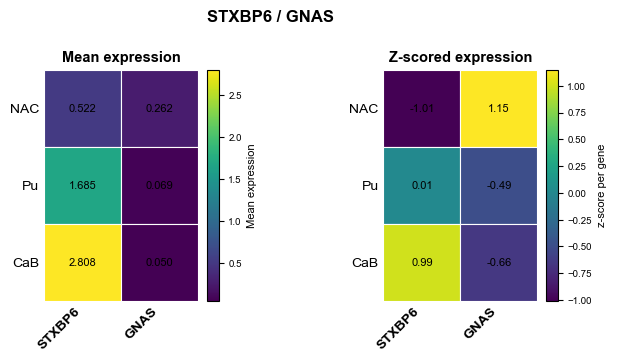

[saved] Region_expression_heatmap/CaB_Pu_NAC_STXBP6_GNAS_raw_and_zscore_heatmaps_editable.pdf
[saved] Region_expression_heatmap/CaB_Pu_NAC_STXBP6_GNAS_raw_and_zscore_heatmaps_editable.svg

=== CaT_CaB_CaH_VSTM4_ANO6: mean expression ===
           VSTM4      ANO6
region                    
CaH     0.094620  0.399845
CaB     0.098203  0.419524
CaT     0.133861  0.560530

=== CaT_CaB_CaH_VSTM4_ANO6: z-scored expression ===
           VSTM4      ANO6
region                    
CaH    -0.657952 -0.685967
CaB    -0.492805 -0.461434
CaT     1.150757  1.147401

=== CaT_CaB_CaH_VSTM4_ANO6: percent expressing cells ===
            VSTM4       ANO6
region                      
CaH      8.146846  27.868345
CaB      8.391544  28.687063
CaT     11.040403  35.207933


/var/folders/_r/b3mmx0vn61xg9lj08b924y_h0000gn/T/ipykernel_41676/2020733302.py:235: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


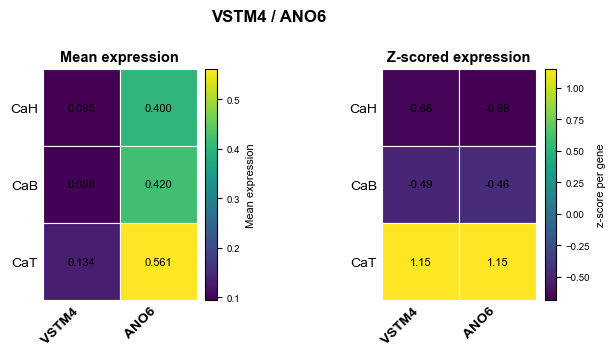

[saved] Region_expression_heatmap/CaT_CaB_CaH_VSTM4_ANO6_raw_and_zscore_heatmaps_editable.pdf
[saved] Region_expression_heatmap/CaT_CaB_CaH_VSTM4_ANO6_raw_and_zscore_heatmaps_editable.svg
[done]


In [3]:
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

# =========================
# Editable PDF settings
# =========================
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"]  = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"]  = "Arial"

adata = sc.read_h5ad("/Users/likai/Downloads/BICAN_MiniAtlas_HQcell_BGC_STR_MSN.h5ad")

SAVE_DIR = "Region_expression_heatmap"
os.makedirs(SAVE_DIR, exist_ok=True)

REGION_COL = "region"

PLOT_SETS = {
    "CaB_Pu_NAC_STXBP6_GNAS": {
        "regions": [ "NAC","Pu","CaB"],
        "genes": ["STXBP6", "GNAS"],
        "title": "STXBP6 / GNAS",
    },
    "CaT_CaB_CaH_VSTM4_ANO6": {
        "regions": ["CaH", "CaB", "CaT"],
        "genes": ["VSTM4", "ANO6"],
        "title": "VSTM4 / ANO6",
    },
}

if REGION_COL not in adata.obs.columns:
    raise ValueError(f"Cannot find '{REGION_COL}' in adata.obs")

print("=== Region counts ===")
print(adata.obs[REGION_COL].astype(str).value_counts())

if adata.raw is not None:
    X_source = adata.raw.X
    var_names = pd.Index(adata.raw.var_names.astype(str).str.upper())
else:
    X_source = adata.X
    var_names = pd.Index(adata.var_names.astype(str).str.upper())

labels = adata.obs[REGION_COL].astype(str).values

CMAP = mpl.colormaps["viridis"]


def draw_editable_heatmap(ax, mat, cmap, vmin=None, vmax=None, fmt=".2f"):
    """
    Draw heatmap using individual Rectangle patches.
    Each cell is editable as a separate vector object in Adobe Illustrator.
    """
    mat = mat.copy()
    values = mat.values.astype(float)

    if vmin is None:
        vmin = np.nanmin(values)
    if vmax is None:
        vmax = np.nanmax(values)

    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-9

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    n_rows, n_cols = mat.shape

    for i in range(n_rows):
        for j in range(n_cols):
            val = values[i, j]
            color = cmap(norm(val))

            rect = mpl.patches.Rectangle(
                (j, i),
                1,
                1,
                facecolor=color,
                edgecolor="white",
                linewidth=0.8,
            )
            ax.add_patch(rect)

            ax.text(
                j + 0.5,
                i + 0.5,
                format(val, fmt),
                ha="center",
                va="center",
                fontsize=8,
                color="black",
            )

    ax.set_xlim(0, n_cols)
    ax.set_ylim(n_rows, 0)
    ax.set_aspect("equal")

    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_xticklabels(
        mat.columns,
        rotation=45,
        ha="right",
        fontsize=10,
        fontweight="bold",
    )

    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_yticklabels(mat.index, fontsize=10)

    ax.tick_params(length=0)

    for spn in ax.spines.values():
        spn.set_visible(False)

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    return sm


for tag, cfg in PLOT_SETS.items():
    REGIONS = cfg["regions"]
    GENES = cfg["genes"]

    missing = [g for g in GENES if g not in var_names]
    if missing:
        raise ValueError(f"{tag}: missing genes in adata: {missing}")

    gene_pos = {g: var_names.get_loc(g) for g in GENES}

    X_gene = X_source[:, [gene_pos[g] for g in GENES]]
    if sp.issparse(X_gene):
        X_gene = X_gene.toarray()
    X_gene = np.asarray(X_gene, dtype=float)

    expr_df = pd.DataFrame(X_gene, columns=GENES, index=adata.obs_names)
    expr_df[REGION_COL] = labels
    expr_df = expr_df[expr_df[REGION_COL].isin(REGIONS)].copy()

    mean_mat = (
        expr_df
        .groupby(REGION_COL)[GENES]
        .mean()
        .reindex(REGIONS)
    )

    pct_mat = (
        expr_df
        .groupby(REGION_COL)[GENES]
        .apply(lambda x: (x > 0).mean() * 100)
        .reindex(REGIONS)
    )

    z_mat = mean_mat.apply(
        lambda x: (x - x.mean()) / (x.std() + 1e-9),
        axis=0,
    ).fillna(0)

    print(f"\n=== {tag}: mean expression ===")
    print(mean_mat)

    print(f"\n=== {tag}: z-scored expression ===")
    print(z_mat)

    print(f"\n=== {tag}: percent expressing cells ===")
    print(pct_mat)

    # =========================
    # Plot raw + z-score as editable vector rectangles
    # =========================
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(7.2, 3.0),
        gridspec_kw={"wspace": 0.55},
    )

    # Raw mean heatmap
    sm1 = draw_editable_heatmap(
        axes[0],
        mean_mat,
        cmap=CMAP,
        vmin=float(np.nanmin(mean_mat.values)),
        vmax=float(np.nanmax(mean_mat.values)),
        fmt=".3f",
    )
    axes[0].set_title(
        "Mean expression",
        fontsize=10.5,
        fontweight="bold",
    )

    cb1 = fig.colorbar(
        sm1,
        ax=axes[0],
        fraction=0.055,
        pad=0.04,
    )
    cb1.set_label("Mean expression", fontsize=8)
    cb1.ax.tick_params(labelsize=7)

    # Z-scored heatmap
    sm2 = draw_editable_heatmap(
        axes[1],
        z_mat,
        cmap=CMAP,
        vmin=float(np.nanmin(z_mat.values)),
        vmax=float(np.nanmax(z_mat.values)),
        fmt=".2f",
    )
    axes[1].set_title(
        "Z-scored expression",
        fontsize=10.5,
        fontweight="bold",
    )

    cb2 = fig.colorbar(
        sm2,
        ax=axes[1],
        fraction=0.055,
        pad=0.04,
    )
    cb2.set_label("z-score per gene", fontsize=8)
    cb2.ax.tick_params(labelsize=7)

    fig.suptitle(
        cfg["title"],
        fontsize=12,
        fontweight="bold",
        y=1.08,
    )

    plt.tight_layout()

    pdf_path = f"{SAVE_DIR}/{tag}_raw_and_zscore_heatmaps_editable.pdf"
    svg_path = f"{SAVE_DIR}/{tag}_raw_and_zscore_heatmaps_editable.svg"

    plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
    plt.savefig(svg_path, format="svg", bbox_inches="tight")

    plt.show()

    mean_mat.to_csv(f"{SAVE_DIR}/{tag}_mean_expression.tsv", sep="\t")
    z_mat.to_csv(f"{SAVE_DIR}/{tag}_zscore_expression.tsv", sep="\t")
    pct_mat.to_csv(f"{SAVE_DIR}/{tag}_pct_expression.tsv", sep="\t")

    print(f"[saved] {pdf_path}")
    print(f"[saved] {svg_path}")

print("[done]")

=== Region counts ===
region
Pu      78265
CaB     75731
CaH     71095
NAC     55542
GP      28544
CaT     13514
STH         7
MGM1        5
Name: count, dtype: int64

=== CaB_Pu_NAC_STXBP6_GNAS: mean expression ===
          SEMA3D       NRG3
region                     
NAC     0.324655  15.205664
Pu      0.244324  18.415179
CaB     0.230698  22.122156

=== CaB_Pu_NAC_STXBP6_GNAS: z-scored expression ===
          SEMA3D      NRG3
region                    
NAC     1.144258 -0.975185
Pu     -0.437944 -0.047908
CaB    -0.706314  1.023093

=== CaB_Pu_NAC_STXBP6_GNAS: percent expressing cells ===
           SEMA3D       NRG3
region                      
NAC     18.429297  91.015808
Pu      14.159586  97.086820
CaB     15.412447  96.892950


/var/folders/_r/b3mmx0vn61xg9lj08b924y_h0000gn/T/ipykernel_41676/2509620692.py:227: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


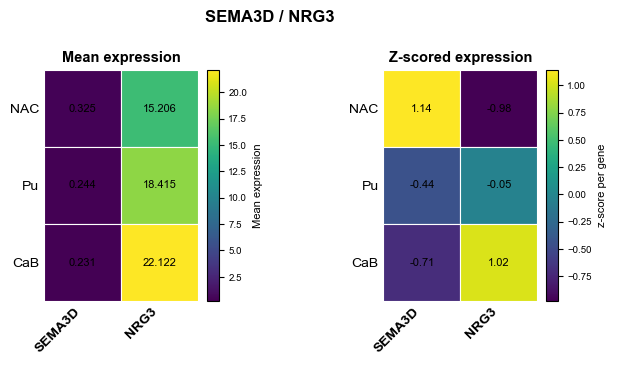

[saved] Region_expression_heatmap/CaB_Pu_NAC_STXBP6_GNAS_raw_and_zscore_heatmaps_editable-4s1.pdf
[saved] Region_expression_heatmap/CaB_Pu_NAC_STXBP6_GNAS_raw_and_zscore_heatmaps_editable-4s1.svg

=== CaT_CaB_CaH_VSTM4_ANO6: mean expression ===
           CDH10     NPAS4
region                    
CaH     0.720374  0.190379
CaB     0.581836  0.134621
CaT     0.311381  0.002960

=== CaT_CaB_CaH_VSTM4_ANO6: z-scored expression ===
           CDH10     NPAS4
region                    
CaH     0.877404  0.842284
CaB     0.211392  0.262904
CaT    -1.088796 -1.105188

=== CaT_CaB_CaH_VSTM4_ANO6: percent expressing cells ===
            CDH10      NPAS4
region                      
CaH     33.960194  11.079541
CaB     27.670307   7.650764
CaT     12.283558   0.288590


/var/folders/_r/b3mmx0vn61xg9lj08b924y_h0000gn/T/ipykernel_41676/2509620692.py:227: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


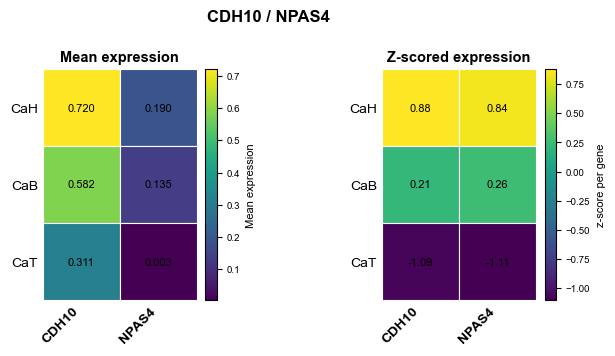

[saved] Region_expression_heatmap/CaT_CaB_CaH_VSTM4_ANO6_raw_and_zscore_heatmaps_editable-4s1.pdf
[saved] Region_expression_heatmap/CaT_CaB_CaH_VSTM4_ANO6_raw_and_zscore_heatmaps_editable-4s1.svg
[done]


In [5]:

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"]  = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"]  = "Arial"

adata = sc.read_h5ad("/Users/likai/Downloads/BICAN_MiniAtlas_HQcell_BGC_STR_MSN.h5ad")

SAVE_DIR = "Region_expression_heatmap"
os.makedirs(SAVE_DIR, exist_ok=True)

REGION_COL = "region"

PLOT_SETS = {
    "CaB_Pu_NAC_STXBP6_GNAS": {
        "regions": [ "NAC","Pu","CaB"],
        "genes": ["SEMA3D", "NRG3"],
        "title": "SEMA3D / NRG3",
    },
    "CaT_CaB_CaH_VSTM4_ANO6": {
        "regions": ["CaH", "CaB", "CaT"],
        "genes": ["CDH10", "NPAS4"],
        "title": "CDH10 / NPAS4",
    },
}

if REGION_COL not in adata.obs.columns:
    raise ValueError(f"Cannot find '{REGION_COL}' in adata.obs")

print("=== Region counts ===")
print(adata.obs[REGION_COL].astype(str).value_counts())

if adata.raw is not None:
    X_source = adata.raw.X
    var_names = pd.Index(adata.raw.var_names.astype(str).str.upper())
else:
    X_source = adata.X
    var_names = pd.Index(adata.var_names.astype(str).str.upper())

labels = adata.obs[REGION_COL].astype(str).values

CMAP = mpl.colormaps["viridis"]


def draw_editable_heatmap(ax, mat, cmap, vmin=None, vmax=None, fmt=".2f"):
    """
    Draw heatmap using individual Rectangle patches.
    Each cell is editable as a separate vector object in Adobe Illustrator.
    """
    mat = mat.copy()
    values = mat.values.astype(float)

    if vmin is None:
        vmin = np.nanmin(values)
    if vmax is None:
        vmax = np.nanmax(values)

    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-9

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    n_rows, n_cols = mat.shape

    for i in range(n_rows):
        for j in range(n_cols):
            val = values[i, j]
            color = cmap(norm(val))

            rect = mpl.patches.Rectangle(
                (j, i),
                1,
                1,
                facecolor=color,
                edgecolor="white",
                linewidth=0.8,
            )
            ax.add_patch(rect)

            ax.text(
                j + 0.5,
                i + 0.5,
                format(val, fmt),
                ha="center",
                va="center",
                fontsize=8,
                color="black",
            )

    ax.set_xlim(0, n_cols)
    ax.set_ylim(n_rows, 0)
    ax.set_aspect("equal")

    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_xticklabels(
        mat.columns,
        rotation=45,
        ha="right",
        fontsize=10,
        fontweight="bold",
    )

    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_yticklabels(mat.index, fontsize=10)

    ax.tick_params(length=0)

    for spn in ax.spines.values():
        spn.set_visible(False)

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    return sm


for tag, cfg in PLOT_SETS.items():
    REGIONS = cfg["regions"]
    GENES = cfg["genes"]

    missing = [g for g in GENES if g not in var_names]
    if missing:
        raise ValueError(f"{tag}: missing genes in adata: {missing}")

    gene_pos = {g: var_names.get_loc(g) for g in GENES}

    X_gene = X_source[:, [gene_pos[g] for g in GENES]]
    if sp.issparse(X_gene):
        X_gene = X_gene.toarray()
    X_gene = np.asarray(X_gene, dtype=float)

    expr_df = pd.DataFrame(X_gene, columns=GENES, index=adata.obs_names)
    expr_df[REGION_COL] = labels
    expr_df = expr_df[expr_df[REGION_COL].isin(REGIONS)].copy()

    mean_mat = (
        expr_df
        .groupby(REGION_COL)[GENES]
        .mean()
        .reindex(REGIONS)
    )

    pct_mat = (
        expr_df
        .groupby(REGION_COL)[GENES]
        .apply(lambda x: (x > 0).mean() * 100)
        .reindex(REGIONS)
    )

    z_mat = mean_mat.apply(
        lambda x: (x - x.mean()) / (x.std() + 1e-9),
        axis=0,
    ).fillna(0)

    print(f"\n=== {tag}: mean expression ===")
    print(mean_mat)

    print(f"\n=== {tag}: z-scored expression ===")
    print(z_mat)

    print(f"\n=== {tag}: percent expressing cells ===")
    print(pct_mat)

    # =========================
    # Plot raw + z-score as editable vector rectangles
    # =========================
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(7.2, 3.0),
        gridspec_kw={"wspace": 0.55},
    )

    # Raw mean heatmap
    sm1 = draw_editable_heatmap(
        axes[0],
        mean_mat,
        cmap=CMAP,
        vmin=float(np.nanmin(mean_mat.values)),
        vmax=float(np.nanmax(mean_mat.values)),
        fmt=".3f",
    )
    axes[0].set_title(
        "Mean expression",
        fontsize=10.5,
        fontweight="bold",
    )

    cb1 = fig.colorbar(
        sm1,
        ax=axes[0],
        fraction=0.055,
        pad=0.04,
    )
    cb1.set_label("Mean expression", fontsize=8)
    cb1.ax.tick_params(labelsize=7)

    # Z-scored heatmap
    sm2 = draw_editable_heatmap(
        axes[1],
        z_mat,
        cmap=CMAP,
        vmin=float(np.nanmin(z_mat.values)),
        vmax=float(np.nanmax(z_mat.values)),
        fmt=".2f",
    )
    axes[1].set_title(
        "Z-scored expression",
        fontsize=10.5,
        fontweight="bold",
    )

    cb2 = fig.colorbar(
        sm2,
        ax=axes[1],
        fraction=0.055,
        pad=0.04,
    )
    cb2.set_label("z-score per gene", fontsize=8)
    cb2.ax.tick_params(labelsize=7)

    fig.suptitle(
        cfg["title"],
        fontsize=12,
        fontweight="bold",
        y=1.08,
    )

    plt.tight_layout()

    pdf_path = f"{SAVE_DIR}/{tag}_raw_and_zscore_heatmaps_editable-4s1.pdf"
    svg_path = f"{SAVE_DIR}/{tag}_raw_and_zscore_heatmaps_editable-4s1.svg"

    plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
    plt.savefig(svg_path, format="svg", bbox_inches="tight")

    plt.show()

    mean_mat.to_csv(f"{SAVE_DIR}/{tag}_mean_expression-4s1.tsv", sep="\t")
    z_mat.to_csv(f"{SAVE_DIR}/{tag}_zscore_expression-4s1.tsv", sep="\t")
    pct_mat.to_csv(f"{SAVE_DIR}/{tag}_pct_expression-4s1.tsv", sep="\t")

    print(f"[saved] {pdf_path}")
    print(f"[saved] {svg_path}")

print("[done]")